# Missense Varyant Sınıflandırma Projesi
Bu not defterinde ClinVar tabanlı genetik varyant verisi üzerinde patojenik-benign sınıflandırması için veri ön işleme, modelleme, dengesiz veri yönetimi, hiperparametre optimizasyonu ve açıklanabilirlik analizi yapılmıştır.

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                            average_precision_score, f1_score, recall_score, precision_score,
                            balanced_accuracy_score)

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

In [77]:
RANDOM_STATE = 42

In [78]:
df = pd.read_csv('clinvar_conflicting.csv',low_memory=False)
print("Shape: ", df.shape)
df.head()

print(df['CLASS'].value_counts(dropna=False))
print(df['CLASS'].value_counts(normalize=True, dropna=False))

Shape:  (65188, 46)
CLASS
0    48754
1    16434
Name: count, dtype: int64
CLASS
0    0.747898
1    0.252102
Name: proportion, dtype: float64


# Veri Temizleme
Eksik değer analizi yapılmış ve yüksek oranda eksik veri içeren sütunlar kaldırılmıştır.

In [79]:
df.columns = df.columns.str.strip()

drop_cols = ['CHROM', 'POS', 'REF','ALT','CLNHGVS','Feature']
df = df.drop(columns=drop_cols, errors="ignore")

In [80]:
print("Duplicate rows: ", df.duplicated().sum())
df = df.drop_duplicates()
print("New shape: ", df.shape)

Duplicate rows:  0
New shape:  (65188, 40)


In [81]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio.head(10)

high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
print("Columns with >50% missing:", high_missing_cols)

Columns with >50% missing: ['MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME', 'DISTANCE', 'SSR', 'CLNDNINCL', 'CLNSIGINCL', 'CLNDISDBINCL', 'INTRON', 'PolyPhen', 'SIFT', 'BLOSUM62', 'CLNVI', 'BAM_EDIT']


# Özellik Dönüşümleri
Bu bölümde biyolojik anlam taşıyan ham özellikler, model için daha anlamlı sayısal temsillere dönüştürülmüştür.

In [82]:
# SIFT anotasyonlarını sayısal forma dönüştürme

def encode_SIFT(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()
    if "deleterious" in val:
        return 1
    if "tolerated" in val:
        return 0
    return np.nan

df['SIFT'] = df['SIFT'].apply(encode_SIFT)

In [83]:
# PolyPhen etki seviyelerini sayısal olarak kodlama

def encode_polyphen(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()
    if "probably_damaging" in val:
        return 2
    elif "possibly_damaging" in val:
        return 1
    elif "benign" in val:
        return 0
    return np.nan

df['PolyPhen'] = df['PolyPhen'].apply(encode_polyphen)

In [84]:
# Amino asit değişimini çıkar ve değişim olup olmadığını belirleme

df['Amino_acids'] = df["Amino_acids"].fillna("X/X")
aa_split = df['Amino_acids'].str.split("/", expand=True)

df["aa_ref"] = aa_split[0]
df["aa_alt"] = aa_split[1]

df["aa_change"] = (df["aa_ref"] != df["aa_alt"]).astype(int)

In [85]:
df["Protein_position"] = df["Protein_position"].str.split("/").str[0]
df["Protein_position"] = pd.to_numeric(df["Protein_position"], errors='coerce')

In [86]:
# EXON bilgisini bölerek sayısal özellikler üretme

df['EXON'] = df['EXON'].fillna('0/0')
exon_split = df['EXON'].str.split('/', expand=True)

df['current_exon'] = pd.to_numeric(exon_split[0], errors='coerce').fillna(0)
df['total_exon'] = pd.to_numeric(exon_split[1], errors='coerce').fillna(0)

df['exon_ratio'] = np.where(df['total_exon'] > 0, df['current_exon'] / df['total_exon'], 0)

df = df.drop(columns='EXON')

In [87]:
df["Consequence"] = df["Consequence"].fillna("unknown")
df["Consequence"] = df["Consequence"].str.split("&").str[0]

df = pd.get_dummies(df, columns=["Consequence"], drop_first=True)

In [88]:
protected_cols = ['SIFT', 'PolyPhen', 'Amino_acids', 'EXON','Protein_position']
drop_after_check = [col for col in high_missing_cols if not col in protected_cols]
df = df.drop(columns=drop_after_check, errors="ignore")

In [89]:
df = df.drop(columns=['PolyPhen', 'Amino_acids','EXON'], errors="ignore")

In [90]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(object_cols)

df = pd.get_dummies(df, columns=['IMPACT', 'BIOTYPE'], drop_first=True)

remaining_object_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Remaining object cols: ", remaining_object_cols)

df = df.drop(columns=remaining_object_cols)

['CLNDISDB', 'CLNDN', 'CLNVC', 'MC', 'Allele', 'IMPACT', 'SYMBOL', 'Feature_type', 'BIOTYPE', 'cDNA_position', 'CDS_position', 'Codons', 'aa_ref', 'aa_alt']
Remaining object cols:  ['CLNDISDB', 'CLNDN', 'CLNVC', 'MC', 'Allele', 'SYMBOL', 'Feature_type', 'cDNA_position', 'CDS_position', 'Codons', 'aa_ref', 'aa_alt']


In [91]:
X = df.drop('CLASS', axis=1)
y = df['CLASS']

numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Veri Bölme
Veri, eğitim ve test seti olarak ayrılmıştır.

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Başlangıç Modeli
Temel performansı görmek için bir başlangıç modeli kurulmuştur.

In [93]:
model = xgb.XGBClassifier(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = RANDOM_STATE,
    eval_metric = 'logloss'
)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)
model_proba = model.predict_proba(X_test)[:, 1]

In [94]:
def evaluate_model(y_true, y_pred, y_proba, model_name="Model"):
    print(f"\n---{model_name}---")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix: ")
    print(confusion_matrix(y_true, y_pred))
    print("ROC-AUC: ", roc_auc_score(y_true, y_proba))
    print("PR-AUC: ", average_precision_score(y_true, y_proba))
    print("Balanced Accuracy: ", balanced_accuracy_score(y_true, y_pred))
    print("Recall: ", recall_score(y_true, y_pred))
    print("Precision: ", precision_score(y_true, y_pred))
    print("F1: ", f1_score(y_true, y_pred))

In [95]:
evaluate_model(y_test, model_pred, model_proba, "Baseline XGBoost")


---Baseline XGBoost---
              precision    recall  f1-score   support

           0       0.78      0.95      0.86      9751
           1       0.58      0.22      0.32      3287

    accuracy                           0.76     13038
   macro avg       0.68      0.58      0.59     13038
weighted avg       0.73      0.76      0.72     13038

Confusion Matrix: 
[[9243  508]
 [2577  710]]
ROC-AUC:  0.7710379068560737
PR-AUC:  0.5003701241176289
Balanced Accuracy:  0.5819526065161867
Recall:  0.21600243383024034
Precision:  0.5829228243021346
F1:  0.31520532741398444


# Dengesiz Veri Problemi
Sınıf dengesizliğini azaltmak için ağırlıklı model denenmiştir.

In [96]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]

# Sınıf dengesizliğini azaltmak için pozitif sınıf ağırlığını hesaplama
scale_pos_weight = neg_count / pos_count

balanced_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)
balanced_proba = balanced_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, balanced_pred, balanced_proba, "Balanced XGBoost")


---Balanced XGBoost---
              precision    recall  f1-score   support

           0       0.88      0.69      0.77      9751
           1       0.44      0.73      0.55      3287

    accuracy                           0.70     13038
   macro avg       0.66      0.71      0.66     13038
weighted avg       0.77      0.70      0.72     13038

Confusion Matrix: 
[[6705 3046]
 [ 892 2395]]
ROC-AUC:  0.7716962060196989
PR-AUC:  0.49782191008157367
Balanced Accuracy:  0.708124855291651
Recall:  0.728627928202008
Precision:  0.44017643815475094
F1:  0.5488084326306141


# Hiperparametre Optimizasyonu
Model performansını artırmak için çapraz doğrulama ile hipermarametre araması yapılmıştır.

In [98]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'max_depth' : [3,5,7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators' : [100,200],
    'subsample' : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

grid_model = xgb.XGBClassifier(
    random_state = RANDOM_STATE,
    eval_metric = 'logloss',
    scale_pos_weight = scale_pos_weight
)

grid_search = GridSearchCV(
    estimator = grid_model,
    param_grid = param_grid,
    scoring = 'recall',
    cv = cv,
    verbose = 1,
    n_jobs = -1
)

grid_search.fit(X_train, y_train)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head()

print("Best Params: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score:  0.7354525929707691


In [99]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, best_pred, best_proba, "Tuned XGBoost")


---Tuned XGBoost---
              precision    recall  f1-score   support

           0       0.88      0.69      0.78      9751
           1       0.44      0.73      0.55      3287

    accuracy                           0.70     13038
   macro avg       0.66      0.71      0.66     13038
weighted avg       0.77      0.70      0.72     13038

Confusion Matrix: 
[[6755 2996]
 [ 887 2400]]
ROC-AUC:  0.7799293369300825
PR-AUC:  0.5093852834715795
Balanced Accuracy:  0.7114492668479517
Recall:  0.7301490721022209
Precision:  0.4447739065974796
F1:  0.5528043303005874


# Eşik - Threshold Analizi
Farklı eşik değerleri modelin duyarlılık ve hassasiyet dengesi incelenmiştir.

In [100]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []
for thr in thresholds:
    pred_thr = (best_proba >= thr).astype(int)
    
    results.append({
        'threshold': thr,
        'recall': recall_score(y_test, pred_thr),
        'precision': precision_score(y_test, pred_thr),
        'f1': f1_score(y_test, pred_thr),
        'balanced_accuracy': balanced_accuracy_score(y_test, pred_thr)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,recall,precision,f1,balanced_accuracy
0,0.10,0.990265,0.285101,0.442737,0.576611
1,0.15,0.983876,0.293626,0.452276,0.593004
2,0.20,0.972924,0.307028,0.466759,0.616346
3,0.25,0.951019,0.329504,0.489432,0.649338
4,0.30,0.923639,0.353352,0.511154,0.676925
5,0.35,0.890782,0.372614,0.525437,0.692596
6,0.40,0.849711,0.392110,0.536599,0.702827
7,0.45,0.792820,0.418836,0.548112,0.710993
8,0.50,0.730149,0.444774,0.552804,0.711449
9,0.55,0.667782,0.470223,0.551854,0.707084


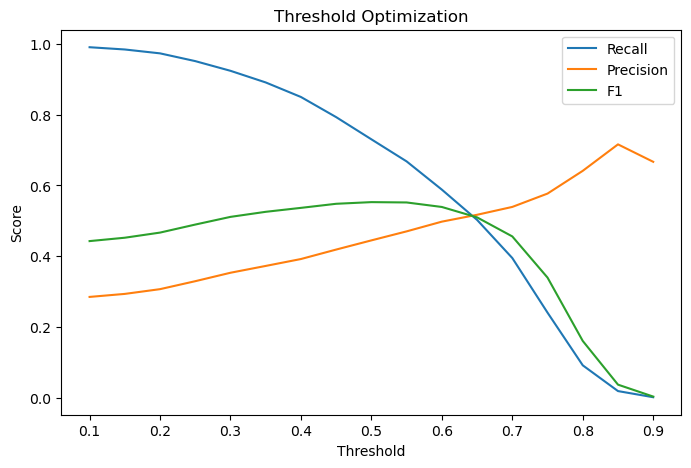

In [101]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Optimization")
plt.show()

# Final Model Değerlendirmesi
Seçilen model test verisi üzerinde değerlendirilmiştir.

In [102]:
# Recall değerini artırmak için uygun eşik seçme

chosen_threshold = 0.35
final_pred = (best_proba >= chosen_threshold).astype(int)

evaluate_model(y_test, final_pred, best_proba, f"Final Model (threshold = {chosen_threshold})")


---Final Model (threshold = 0.35)---
              precision    recall  f1-score   support

           0       0.93      0.49      0.65      9751
           1       0.37      0.89      0.53      3287

    accuracy                           0.59     13038
   macro avg       0.65      0.69      0.59     13038
weighted avg       0.79      0.59      0.62     13038

Confusion Matrix: 
[[4821 4930]
 [ 359 2928]]
ROC-AUC:  0.7799293369300825
PR-AUC:  0.5093852834715795
Balanced Accuracy:  0.692596348811603
Recall:  0.8907818679647095
Precision:  0.3726138966658183
F1:  0.5254374158815612


# Özellik Önemleri ve Model Yorumlanabilirliği
Modelin kararlarını en çok etkileyen özellikler incelenmiştir ve tahminlerini açıklamak için SHAP analizi yapılmıştır.

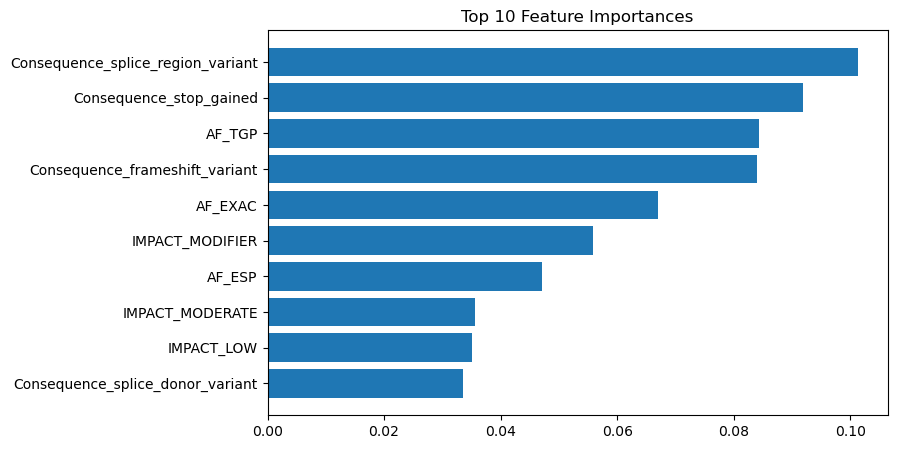

In [103]:
importances = best_model.feature_importances_
feat_names = X.columns

feat_imp = pd.DataFrame({
    'feature':feat_names,
    'importance':importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

plt.figure(figsize=(8,5))
plt.barh(feat_imp['feature'].head(10), feat_imp['importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

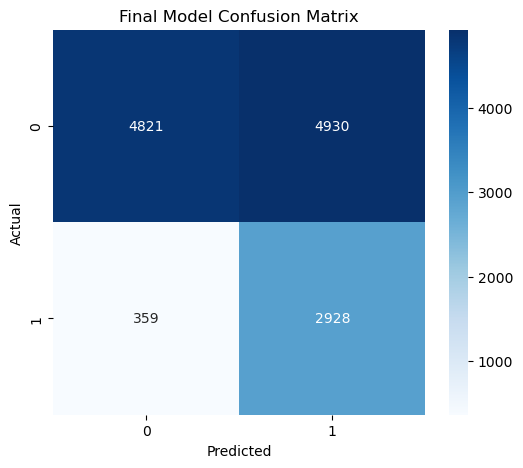

In [107]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

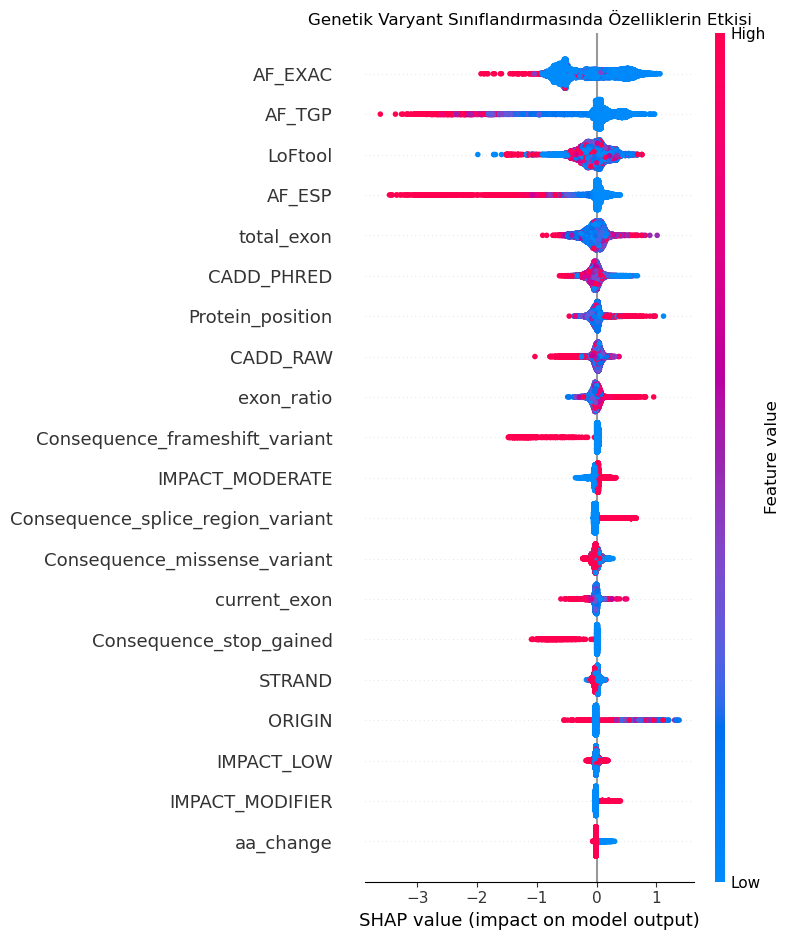

In [109]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Genetik Varyant Sınıflandırmasında Özelliklerin Etkisi")

plt.tight_layout()
plt.show()

# Sonuç
Model performansı artırılmış ve özellikle patojenik sınıfın yakalanması iyileştirilmiştir. Eşik analizi ile daha güvenli bir karar mekanizması elde edilmiştir.